<a href="https://colab.research.google.com/github/Kiritthika03/House_prediction/blob/main/House_predictiction_Random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/House Price Prediction Dataset.csv')

In [ ]:
df.head(20)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [ ]:
df.shape

(2000, 12)

In [ ]:
df['Location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [ ]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
categorical_cols = df.select_dtypes(include = ['object']).columns
print(categorical_cols)

Index(['Location', 'Condition', 'Garage'], dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()

for cols in categorical_cols:
    df[cols] = le.fit_transform(df[cols])

df.head(20)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,0,0,0,149919
1,2,4272,5,4,3,1958,0,0,0,424998
2,3,3592,2,2,3,1938,0,2,0,266746
3,4,966,4,2,2,1902,2,1,1,244020
4,5,4926,1,4,2,1975,0,1,1,636056
5,6,3944,1,2,1,1906,3,3,0,93262
6,7,3671,1,1,2,1948,1,3,1,448722
7,8,3419,2,4,1,1925,2,2,1,594893
8,9,630,2,2,1,1932,1,3,1,652878
9,10,2185,3,3,1,2000,0,3,0,340375


In [ ]:
print(df['YearBuilt'].min())
print(df['YearBuilt'].max())

1900
2023


In [ ]:
df['PropertyAge'] = df['YearBuilt'].max() - df['YearBuilt']

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,PropertyAge
0,1,1360,5,4,3,1970,0,0,0,149919,53
1,2,4272,5,4,3,1958,0,0,0,424998,65
2,3,3592,2,2,3,1938,0,2,0,266746,85
3,4,966,4,2,2,1902,2,1,1,244020,121
4,5,4926,1,4,2,1975,0,1,1,636056,48


In [ ]:
df['PricePerSqFt'] = df['Price'] / df['Area']

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,PropertyAge,PricePerSqFt
0,1,1360,5,4,3,1970,0,0,0,149919,53,110.234559
1,2,4272,5,4,3,1958,0,0,0,424998,65,99.484551
2,3,3592,2,2,3,1938,0,2,0,266746,85,74.261136
3,4,966,4,2,2,1902,2,1,1,244020,121,252.608696
4,5,4926,1,4,2,1975,0,1,1,636056,48,129.122209


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price,PropertyAge,PricePerSqFt
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,1.447500,1.482000,0.481000,537676.855000,61.554000,270.808690
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,1.136173,1.126193,0.499764,276428.845719,35.926695,267.339078
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,0.000000,0.000000,0.000000,50005.000000,0.000000,11.451724
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,0.000000,0.000000,0.000000,300098.000000,30.000000,109.895401
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,1.000000,1.000000,0.000000,539254.000000,62.000000,195.798127
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,2.000000,3.000000,1.000000,780086.000000,93.000000,318.894265
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,3.000000,3.000000,1.000000,999656.000000,123.000000,1909.211132


# EDA

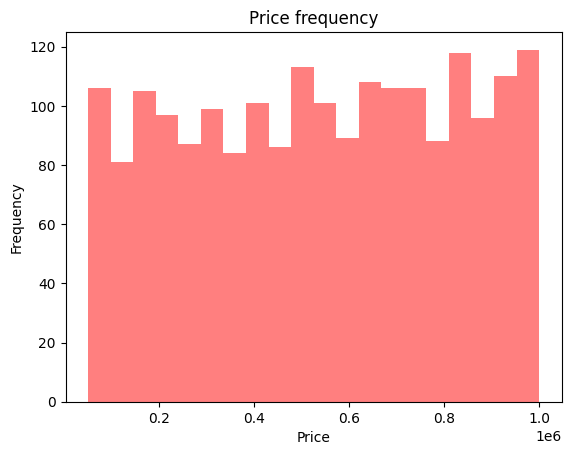

In [ ]:
plt.hist(df['Price'],bins=20, color = 'Red', alpha = 0.5)
plt.title('Price frequency')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
 df['Price'].skew()

-0.06435063707629374

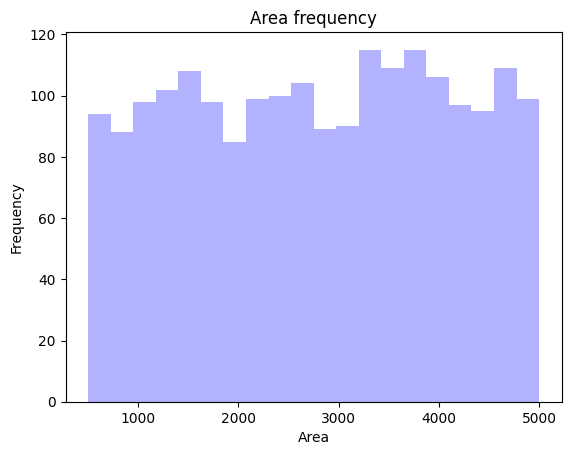

In [ ]:
plt.hist(df['Area'], bins = 20 , color = 'Blue', alpha = 0.3)
plt.title('Area frequency')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df['Area'].skew()

-0.03855182209251573

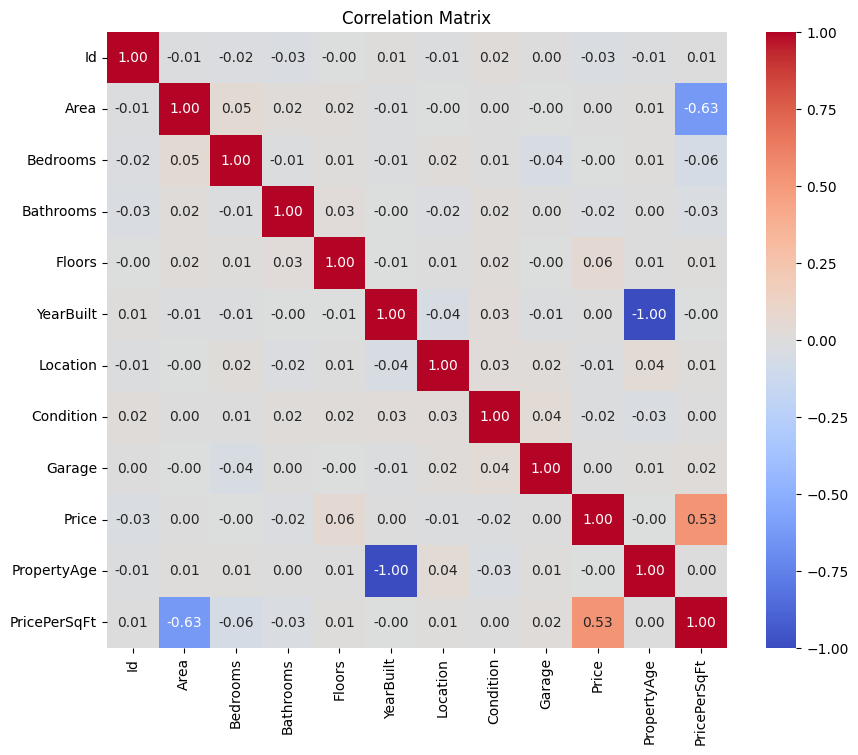

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


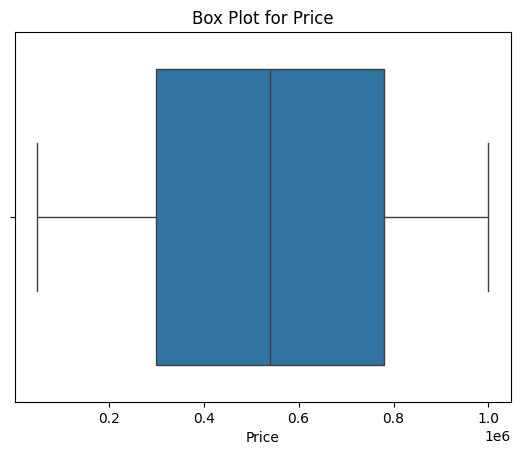

In [ ]:
sns.boxplot(x=df['Price'])
plt.title('Box Plot for Price')
plt.show()



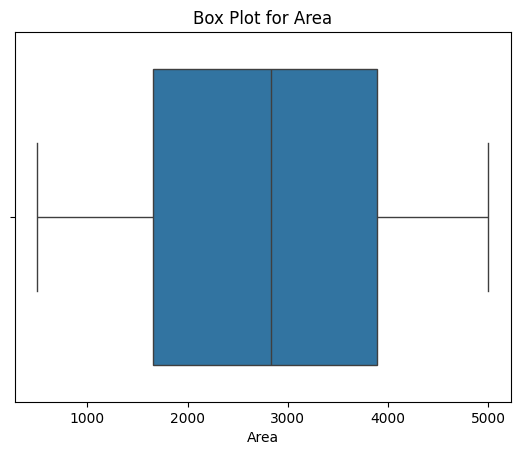

In [ ]:
sns.boxplot(x=df['Area'])
plt.title('Box Plot for Area')
plt.show()

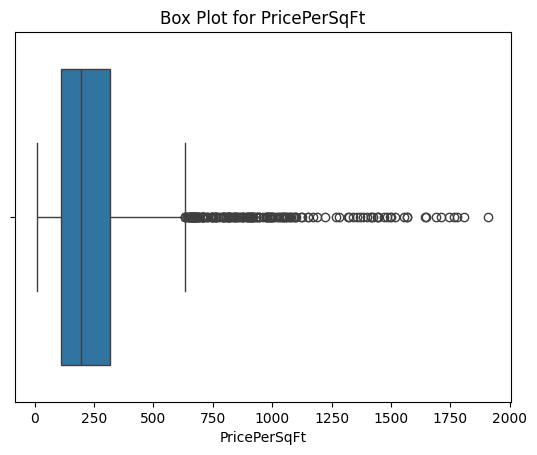

In [ ]:
sns.boxplot(x=df['PricePerSqFt'])
plt.title('Box Plot for PricePerSqFt')
plt.show()

In [ ]:
correlation_with_price = df.corr()['Price'].sort_values(ascending=False)

# Display correlations with 'Price'
print("Correlation of features with Price:")
print(correlation_with_price)

Correlation of features with Price:
Price           1.000000
PricePerSqFt    0.525243
Floors          0.055890
YearBuilt       0.004845
Garage          0.002842
Area            0.001542
Bedrooms       -0.003471
PropertyAge    -0.004845
Location       -0.012289
Condition      -0.015036
Bathrooms      -0.015737
Id             -0.025643
Name: Price, dtype: float64


# Training the model

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
X = df.drop(['Price', 'Id'], axis=1)
y = df['Price']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

In [ ]:
rf_model = RandomForestRegressor(n_estimators = 50, random_state = 42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
print(f'Root mean squared error: {rmse}')
print(f'R square: {r2}')

Root mean squared error: 17435.94225631804
R square: 0.996092330846757


# Predictive system

In [ ]:
def predict_price(features):
  input_features = [features]
  prediction = rf_model.predict(input_features)
  return prediction[0]

In [ ]:
price_prediction = predict_price([1500, 3, 2, 2, 2010, 1, 2, 1, 13, 400])
print(price_prediction)

620812.24


/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

# Save the trained Random Forest model to a file
with open('rf_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Model saved successfully as rf_model.pkl")


Model saved successfully as rf_model.pkl
